In [1]:
import pandas as pd

import nltk
from nltk.tokenize import sent_tokenize

import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.notebook import tqdm

In [ ]:
path = 'relabel_cleaned_articles_dataset.csv'

In [4]:
data = pd.read_csv(path)

In [5]:
data.rename(columns={"label_3": "label"}, inplace=True)

# Process Dataset

In [6]:
# Download German language data
nltk.download('punkt')
nltk.download('punkt_tab')


def get_first_n_sentences(text, n):
    if pd.isna(text) or text.strip() == '':
        return text

    sentences = sent_tokenize(str(text), language='german')
    return ' '.join(sentences[:n])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [7]:
data['text'] = data['text'].apply(lambda x: get_first_n_sentences(x, 10))

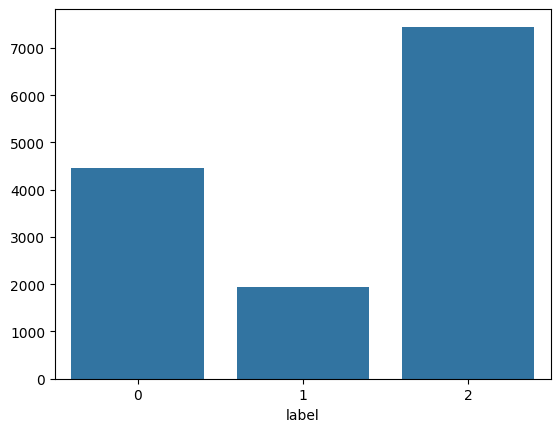

In [8]:
bias_vals = data['label'].value_counts()
plt.figure()
sns.barplot(x=bias_vals.index, y=bias_vals.values)
plt.show();

# Train/Test/Val Data Preparation

In [9]:
# Train/Val and Test
df_train_val, df_test = train_test_split(data, test_size=0.1, stratify=data['label'], random_state=42)

# Train/Val -> Train and Validation
df_train, df_val = train_test_split(df_train_val, test_size=0.1111, stratify=df_train_val['label'], random_state=42)

print(f"Train size: {len(df_train)}, Val size: {len(df_val)}, Test size: {len(df_test)}")

Train size: 11083, Val size: 1386, Test size: 1386


In [11]:
print(df_train['text'].iloc[2])
print(len(df_train['text'].iloc[2]))
print(df_val['text'].iloc[2])
print(len(df_val['text'].iloc[2]))
print(df_test['text'].iloc[2])
print(len(df_test['text'].iloc[2]))

Forschungsministerin plant Wasserstoff-Partnerschaft mit Australien Bundesforschungsministerin Anja Karliczek (CDU) plant eine Wasserstoff-Partnerschaft mit Australien. „Wir wollen dort eine Demonstrationsanlage zur industriellen Produktion mitunterstützen“, sagte sie der WirtschaftsWoche. Australien sei ein politisch stabiles Industrieland und für die Produktion von Grünem Wasserstoff prädestiniert. In den kommenden Wochen wird die Bundesregierung ihre Wasserstoffstrategie vorstellen. Wasserstoff sei der Energieträger der Zukunft, betonte Karliczek: „Deutschland muss diese Zukunftstechnologie nutzen und weiterentwickeln, um hier einer, wenn nicht der Weltmarkführer zu werden.“ Ihr Fokus liege auf Grünem Wasserstoff – also auf dem Wasserstoff, der aus Wind- und Sonnenenergie erzeugt wird. Potenziale sieht die Forschungsministerin vor allem in der Industrie. „Über Wasserstoff können wir deren Kohlendioxidemissionen un glaublich reduzieren“, sagte sie der WirtschaftsWoche. Dass Wassersto

In [13]:
training_file_path = "/content/drive/MyDrive/Colab Notebooks/t1an/data/training.csv"
validation_file_path = "/content/drive/MyDrive/Colab Notebooks/t1an/data/validation.csv"
testing_file_path = "/content/drive/MyDrive/Colab Notebooks/t1an/data/testing.csv"

df_train.to_csv(training_file_path, index=False)
df_val.to_csv(validation_file_path, index=False)
df_test.to_csv(testing_file_path, index=False)

In [14]:
class PoliticalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Model

In [15]:
model_name = 'deepset/gelectra-base'
output_dir = "/content/drive/MyDrive/Colab Notebooks/t1an/GELECTRA-base"

In [17]:
# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
'''
token_lengths = []
for text in data['text'].values:
    tokens = tokenizer.encode(str(text))
    token_lengths.append(len(tokens))

print(f"Max: {max(token_lengths)}")
print(f"Mean: {np.mean(token_lengths):.0f}")
print(f"95th percentile: {np.percentile(token_lengths, 95):.0f}")
print(f"99th percentile: {np.percentile(token_lengths, 99):.0f}")
'''

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/83.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

'\ntoken_lengths = []\nfor text in data[\'text\'].values:\n    tokens = tokenizer.encode(str(text))\n    token_lengths.append(len(tokens))\n\nprint(f"Max: {max(token_lengths)}")\nprint(f"Mean: {np.mean(token_lengths):.0f}")\nprint(f"95th percentile: {np.percentile(token_lengths, 95):.0f}")\nprint(f"99th percentile: {np.percentile(token_lengths, 99):.0f}")\n'

In [ ]:
#l = 256

In [18]:
b_size = 16
num_epochs = 8

In [19]:
# Create dataset instances
train_dataset = PoliticalDataset(
    texts=df_train['text'].values,
    labels=df_train['label'].values,
    tokenizer=tokenizer,
    max_len=512
)

val_dataset = PoliticalDataset(
    texts=df_val['text'].values,
    labels=df_val['label'].values,
    tokenizer=tokenizer,
    max_len=512
)

test_dataset = PoliticalDataset(
    texts=df_test['text'].values,
    labels=df_test['label'].values,
    tokenizer=tokenizer,
    max_len=512
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=b_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=b_size, shuffle=False)

In [20]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: deepset/gelectra-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(31102, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [21]:
optimizer = AdamW(model.parameters(), lr=2e-5)


num_training_steps = len(train_loader) * num_epochs
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [22]:
#Calculate Class Weights

classes = np.unique(df_train['label'].values)
class_weights = compute_class_weight('balanced', classes=classes, y=df_train['label'].values)
print("Class Weights:", class_weights)

Class Weights: [1.03337995 2.38652024 0.61985459]


In [23]:
#Define the Custom Loss Function
class_weights = torch.tensor(class_weights, dtype=torch.float32)

# Send class_weights to the same device as the model (GPU or CPU)
class_weights = class_weights.to(device)

# Define a custom loss function with class weights
loss_fn = nn.CrossEntropyLoss(weight=class_weights).to(device)

In [24]:
def train_epoch(model, data_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0

    for batch in tqdm(data_loader, desc="Training", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            #labels=labels
        )
        #loss = outputs.loss

        logits = outputs.logits  # shape [batch_size, num_classes]

        # Compute custom weighted loss
        loss = loss_fn(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [25]:
def eval_model(model, data_loader, device, loss_fn):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0

    # Collect all predictions and labels for detailed metrics
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                #labels=labels
            )
            #loss = outputs.loss

            logits = outputs.logits
            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            # Accuracy
            preds = torch.argmax(logits, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_predictions += labels.size(0)

            # Collect predictions and labels
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_predictions

    report = classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1, 2],
        target_names=['0', '1', '2'],
        output_dict=True,
        zero_division=0
    )
    report['accuracy'] = accuracy
    report['all_predictions'] = all_predictions
    report['all_labels'] = all_labels

    return avg_loss, accuracy, report

In [26]:
best_val_loss = float('inf')
patience = 2
patience_counter = 0

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}:")

    train_loss = train_epoch(model, train_loader, optimizer, device, loss_fn)
    val_loss, val_accuracy, val_report = eval_model(model, val_loader, device, loss_fn)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy*100:.2f}%")
    print(f"\nDetailed Validation Metrics:")
    print(f"Macro F1: {val_report['macro avg']['f1-score']:.3f}")
    print(f"Weighted F1: {val_report['weighted avg']['f1-score']:.3f}")
    print("\nPer-Class Performance:")
    for idx, class_name in enumerate(['Left', 'Center', 'Right']):
        class_metrics = val_report[str(idx)]
        print(f"{class_name:>12}: "
              f"Precision={class_metrics['precision']:.3f}, "
              f"Recall={class_metrics['recall']:.3f}, "
              f"F1={class_metrics['f1-score']:.3f}, "
              f"Support={int(class_metrics['support'])}")

    # Best model checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        model.save_pretrained(output_dir)
        tokenizer.save_pretrained(output_dir)
        print(f"New best model saved (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    print("-"*60)

    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/8:


Training:   0%|          | 0/693 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

Train Loss: 0.7868
Val Loss: 0.4869 | Val Accuracy: 80.81%

Detailed Validation Metrics:
Macro F1: 0.774
Weighted F1: 0.825

Per-Class Performance:
        Left: Precision=0.892, Recall=0.814, F1=0.851, Support=447
      Center: Precision=0.456, Recall=0.892, F1=0.604, Support=194
       Right: Precision=0.973, Recall=0.783, F1=0.868, Support=745


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

Train Loss: 0.2657
Val Loss: 0.3473 | Val Accuracy: 87.73%

Detailed Validation Metrics:
Macro F1: 0.845
Weighted F1: 0.885

Per-Class Performance:
        Left: Precision=0.941, Recall=0.890, F1=0.915, Support=447
      Center: Precision=0.587, Recall=0.887, F1=0.706, Support=194
       Right: Precision=0.964, Recall=0.867, F1=0.913, Support=745
No improvement. Patience: 1/2
------------------------------------------------------------
Epoch 4/8:


Training:   0%|          | 0/693 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

Train Loss: 0.1711
Val Loss: 0.3824 | Val Accuracy: 87.88%

Detailed Validation Metrics:
Macro F1: 0.846
Weighted F1: 0.883

Per-Class Performance:
        Left: Precision=0.912, Recall=0.928, F1=0.920, Support=447
      Center: Precision=0.623, Recall=0.835, F1=0.714, Support=194
       Right: Precision=0.955, Recall=0.860, F1=0.905, Support=745
No improvement. Patience: 2/2
------------------------------------------------------------
Early stopping triggered at epoch 4


In [27]:
# Reload the best model for testing
model = AutoModelForSequenceClassification.from_pretrained(output_dir)
model.to(device)
print(f"\nBest model reloaded from checkpoint (best val_loss: {best_val_loss:.4f})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Best model reloaded from checkpoint (best val_loss: 0.3434)


In [28]:
test_loss, test_accuracy, test_report = eval_model(model, test_loader, device, loss_fn)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy*100:.2f}%")

print(f"\nDetailed Test Metrics:")
print(f"Macro F1: {test_report['macro avg']['f1-score']:.3f}")
print(f"Weighted F1: {test_report['weighted avg']['f1-score']:.3f}")
print("\nPer-Class Performance:")
for idx, class_name in enumerate(['Left', 'Center', 'Right']):
    class_metrics = test_report[str(idx)]
    print(f"{class_name:>12}: "
          f"Precision={class_metrics['precision']:.3f}, "
          f"Recall={class_metrics['recall']:.3f}, "
          f"F1={class_metrics['f1-score']:.3f}, "
          f"Support={int(class_metrics['support'])}")

cm = confusion_matrix(test_report['all_labels'], test_report['all_predictions'])
print("\nConfusion Matrix:")
print("Predicted:    Left  Center  Right")
for i, (row, name) in enumerate(zip(cm, ['Left', 'Center', 'Right'])):
    print(f"Actual {name:>7}: {row}")

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

Test Loss: 0.3996 | Test Accuracy: 82.54%

Detailed Test Metrics:
Macro F1: 0.794
Weighted F1: 0.840

Per-Class Performance:
        Left: Precision=0.927, Recall=0.801, F1=0.860, Support=447
      Center: Precision=0.491, Recall=0.938, F1=0.644, Support=194
       Right: Precision=0.960, Recall=0.811, F1=0.879, Support=745

Confusion Matrix:
Predicted:    Left  Center  Right
Actual    Left: [358  70  19]
Actual  Center: [  6 182   6]
Actual   Right: [ 22 119 604]


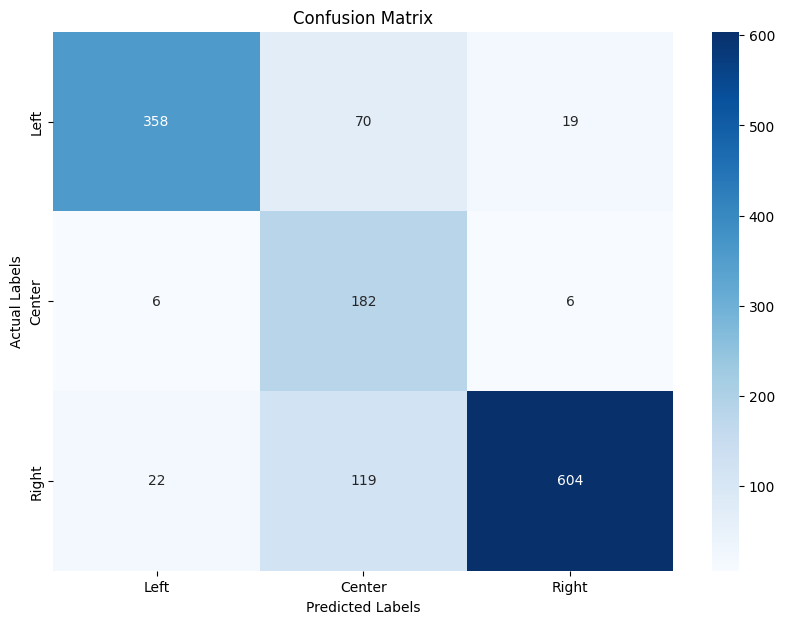

In [29]:
label_names = ['Left', 'Center', 'Right']

cm = confusion_matrix(test_report['all_labels'], test_report['all_predictions'])
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.savefig(output_dir + '/confusion_matrix.png', format='png', bbox_inches='tight')
plt.show()